In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# Data Acquisition & Preparation
# we are using Oxford-IIIT Pet Dataset

Why this dataset?

37 pet breeds

Both cats and dogs

Labeled images

Balanced dataset

High quality


In [ ]:
dataset, info = tfds.load(
    'oxford_iiit_pet',
    with_info=True,
    as_supervised=True
)

train_data = dataset['train']
test_data = dataset['test']

NUM_CLASSES = info.features['label'].num_classes
print("Number of Classes:", NUM_CLASSES)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.Z36EE4_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.Z36EE4_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of Classes: 37


## **Image Preprocessing**

We need:

Resize images to 224x224

Normalize pixel values (0–1)

In [ ]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess)
test_data = test_data.map(preprocess)

**Data** **Augmentation**

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [ ]:
BATCH_SIZE = 32

train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# **Model Architecture: MobileNetV2** (Transfer Learning)

Why?

Lightweight

High accuracy

Pretrained on ImageNet

Works well for 224x224 images

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(37, activation='softmax')  # 37 breeds
])

In [ ]:
model.build(input_shape=(None, 224, 224, 3))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Architecture Flow**

Input Image (224x224x3)

        ↓
Data Augmentation

        ↓
MobileNetV2 (Pretrained CNN)

        ↓
Global Average Pooling

        ↓
Dropout (0.3)

        ↓
Dense (128, ReLU)

        ↓
Dense (37, Softmax)

        ↓
Breed Prediction

# Model Compilation & Training

Adam → Adaptive optimizer, works well for deep networks

Sparse categorical crossentropy → Labels are integers (0–36)

Accuracy → Main performance metric

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

# **Train the** **Model**

In [ ]:
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 440s 4s/step - accuracy: 0.0932 - loss: 3.4941 - val_accuracy: 0.3232 - val_loss: 2.8656 - learning_rate: 1.0000e-04
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 421s 4s/step - accuracy: 0.2989 - loss: 2.7002 - val_accuracy: 0.6228 - val_loss: 2.0026 - learning_rate: 1.0000e-04
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 457s 4s/step - accuracy: 0.4818 - loss: 2.0204 - val_accuracy: 0.7509 - val_loss: 1.3288 - learning_rate: 1.0000e-04
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 412s 4s/step - accuracy: 0.5918 - loss: 1.5323 - val_accuracy: 0.7907 - val_loss: 0.9775 - learning_rate: 1.0000e-04
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 444s 4s/step - accuracy: 0.6394 - loss: 1.3028 - val_accuracy: 0.8174 - val_loss: 0.7987 - learning_rate: 1.0000e-04
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 446s 4s/step - accuracy: 0.6717 - loss: 1.1265 - val_accuracy: 0.8318 - val_loss: 0.6899 - learning_rate: 1.0000e-04
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 414s 4s/step - acc

# **Evaluation & Optimization**
Plot Accuracy & Loss Graphs

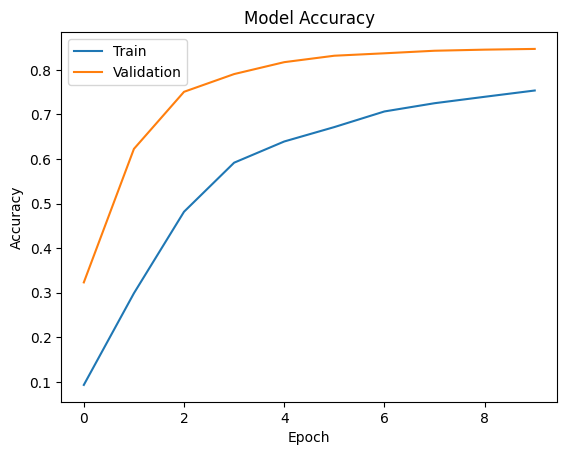

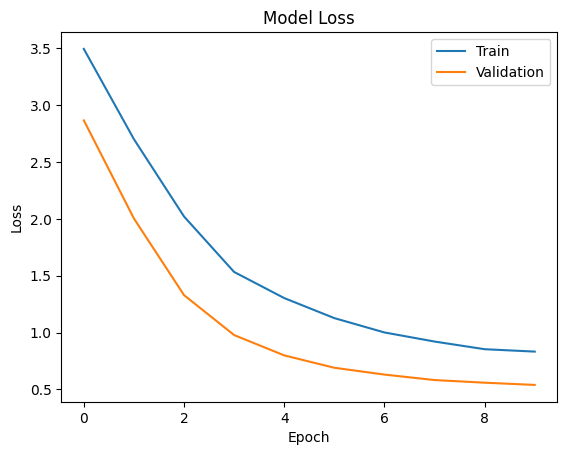

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

115/115 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8471 - loss: 0.5390
Test Accuracy: 0.8470972776412964
Test Loss: 0.5389712452888489


# Confusion Matrix

In [ ]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

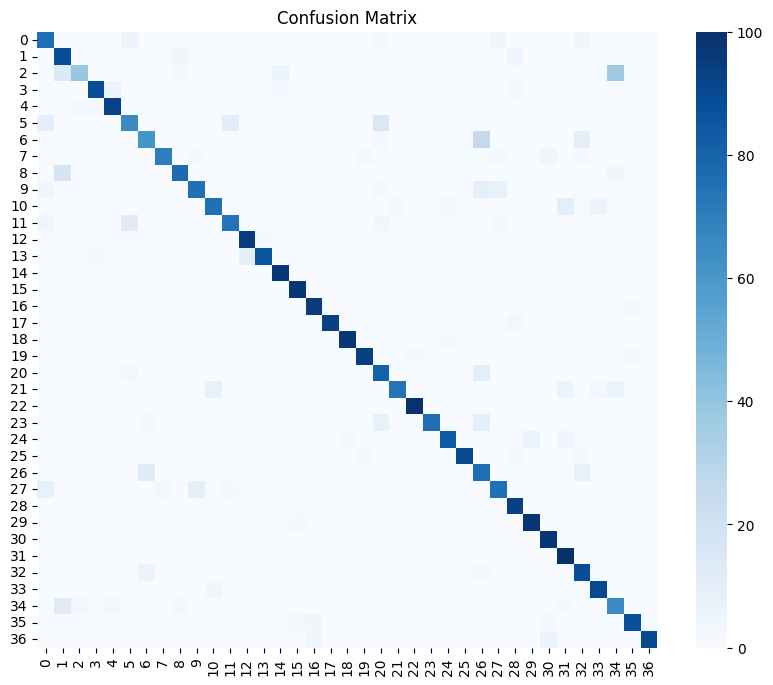

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75        98
           1       0.67      0.89      0.76       100
           2       0.83      0.39      0.53       100
           3       0.95      0.89      0.92       100
           4       0.89      0.93      0.91       100
           5       0.73      0.65      0.69       100
           6       0.75      0.61      0.67       100
           7       0.95      0.80      0.86        88
           8       0.87      0.78      0.82        99
           9       0.86      0.75      0.80       100
          10       0.84      0.75      0.79       100
          11       0.85      0.76      0.80        97
          12       0.88      0.95      0.91       100
          13       0.96      0.86      0.91       100
          14       0.90      0.97      0.93       100
          15       0.92      0.98      0.95       100
          16       0.91      0.95      0.93       100
          17       0.95    

# Fine-Tuning (For Optimization)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
fine_tune_epochs = 5

history_fine = model.fit(
    train_data,
    validation_data=test_data,
    epochs=fine_tune_epochs
)

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 477s 4s/step - accuracy: 0.6685 - loss: 1.1598 - val_accuracy: 0.8550 - val_loss: 0.4999
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 492s 4s/step - accuracy: 0.7209 - loss: 0.9774 - val_accuracy: 0.8561 - val_loss: 0.4819
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 508s 4s/step - accuracy: 0.7302 - loss: 0.9189 - val_accuracy: 0.8585 - val_loss: 0.4690
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 477s 4s/step - accuracy: 0.7476 - loss: 0.8509 - val_accuracy: 0.8580 - val_loss: 0.4591
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 450s 4s/step - accuracy: 0.7503 - loss: 0.8149 - val_accuracy: 0.8613 - val_loss: 0.4479


In [22]:
model.save("pet_breed_classifier.h5")

# Examples

In [23]:
class_names = info.features['label'].names
print(class_names)

['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


In [24]:
cat_breeds = class_names[:12]
dog_breeds = class_names[12:]

In [25]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model):
    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    breed_name = class_names[predicted_index]

    # Identify Cat or Dog
    if breed_name[0].isupper():
        animal_type = "Cat"
    else:
        animal_type = "Dog"

    print("Animal Type:", animal_type)
    print("Breed:", breed_name)
    print("Confidence: {:.2f}%".format(confidence))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{animal_type} - {breed_name}\nConfidence: {confidence:.2f}%")
    plt.show()

In [30]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-03-18 at 9.02.42 PM.jpeg to WhatsApp Image 2026-03-18 at 9.02.42 PM.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
Animal Type: Dog
Breed: pug
Confidence: 91.10%


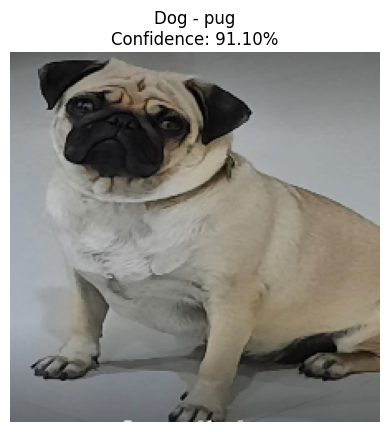

In [31]:
predict_image("WhatsApp Image 2026-03-18 at 9.02.42 PM.jpeg", model)

In [42]:
from google.colab import files
uploaded = files.upload()

Saving timo-volz-ZlFKIG6dApg-unsplash.jpg to timo-volz-ZlFKIG6dApg-unsplash.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Animal Type: Cat
Breed: Abyssinian
Confidence: 93.16%


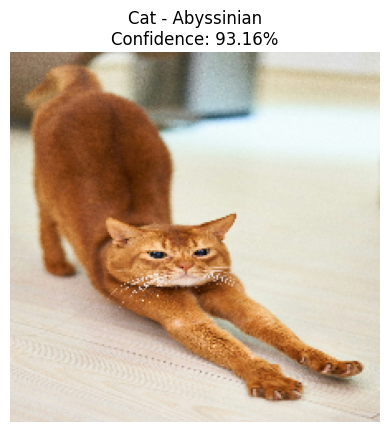

In [43]:
predict_image("timo-volz-ZlFKIG6dApg-unsplash.jpg", model)

In [56]:
from google.colab import files
uploaded = files.upload()

Saving katrinbechtel-dog-7956828_1920.jpg to katrinbechtel-dog-7956828_1920.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
Animal Type: Dog
Breed: german_shorthaired
Confidence: 58.08%


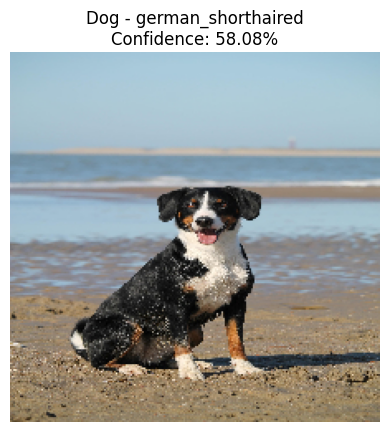

In [57]:
predict_image("katrinbechtel-dog-7956828_1920.jpg", model)

In [60]:
from google.colab import files
uploaded = files.upload()

Saving pexels-tranmautritam-954720.jpg to pexels-tranmautritam-954720.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Animal Type: Cat
Breed: Persian
Confidence: 60.71%


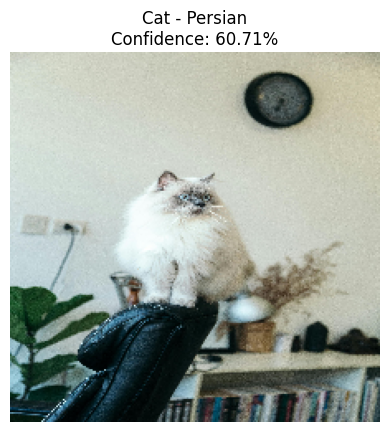

In [61]:
predict_image("pexels-tranmautritam-954720.jpg", model)